In [1]:
import json
import os 
import glob
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
# copy from notebook 3
class LazyDatasetList(Dataset):
    def __init__(self, data_files, transform=None, time_interval=timedelta(minutes=10)):
        self.data_files=data_files
        self.transform = transform
        self.time_interval = time_interval

        # Build a mapping from datetime -> filepath
        self.time_format = "%Y%m%d%H%M"
        self.time_to_file = {}
        for f in self.data_files:
            ts = os.path.splitext(os.path.basename(f))[0]
            try:
                dt = datetime.strptime(ts, self.time_format)
                self.time_to_file[dt] = f
            except ValueError:
                continue  # Skip malformed filenames

        # Sort the datetimes
        sorted_times = sorted(self.time_to_file.keys())

        # Build valid pairs [t-interval, t]
        self.time_list = []
        for t in sorted_times:
            next_t = t - self.time_interval #t-1
            next_t_2 = next_t - self.time_interval #t-2
            next_t_3 = next_t_2 - self.time_interval #t-3
            if next_t in self.time_to_file and next_t_2 in self.time_to_file and next_t_3 in self.time_to_file:
                self.time_list.append((self.time_to_file[t], 
                                       self.time_to_file[next_t], 
                                       self.time_to_file[next_t_2], 
                                       self.time_to_file[next_t_3]))

    def __len__(self):
        return len(self.time_list)

    def __getitem__(self, idx):
        f_t, f_t_1, f_t_2, f_t_3 = self.time_list[idx]
        full_str = f'{os.path.basename(f_t_3)},{os.path.basename(f_t_2)},{os.path.basename(f_t_1)},{os.path.basename(f_t)}'
        # Load data
        data_list = []
        for t_step in [f_t_3, f_t_2, f_t_1, f_t]:
            data=torch.load(t_step).unsqueeze(0)
            if self.transform:
                data = self.transform(data)
            data_list.append(data)
        data=torch.cat(data_list, dim=0)

        return {'data': data, 'source': full_str}

class MinMaxToMinusOneOne:
    def __init__(self, min_vals, max_vals, ):
        self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
        self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)
        
    def __call__(self, x):
        # x: [C, H, W]
        x = (x - self.min_vals) / (self.max_vals - self.min_vals + 1e-6)  # → [0, 1]
        return x * 2.0 - 1.0  # → [-1, 1]

In [3]:
from dataclasses import dataclass
import torch
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from safetensors.torch import load_file

In [5]:
@dataclass
class EvaluationConfig:
    in_channels=4
    out_channels=1
    image_size = 64  # the generated image resolution
    eval_batch_size = 2  # how many images to sample during evaluation
    output_dir = "/scratch/nf33/cd3022/pyearth/model"  # the model name locally and on the HF Hub
    seed = 0


@torch.no_grad()
def evaluate_conditioned(config, model, noise_scheduler, batch):
    device = torch.device("cuda")
    condition_images = batch['data'][:, 0:3, :, :].detach().to(device) 
    
    # 2. Initialize random noise image
    image_shape = (condition_images.shape[0], config.out_channels, config.image_size, config.image_size)  # (B, C, H, W)
    image = torch.randn(image_shape, device=device)
    # 3. Reverse diffusion process
    for t in noise_scheduler.timesteps:
        x_t = torch.cat([image, condition_images], dim=1).to(torch.float32)
        # Predict noise residual
        noise_pred = model(
            x_t,
            t.expand(config.eval_batch_size).to(torch.float32).to(device),  
            return_dict=False
        )[0].to(device)

        # Denoise
        image = noise_scheduler.step(noise_pred, t.cpu(), image).prev_sample

    image_list = list(image.cpu())
    return image_list

In [6]:
config = EvaluationConfig()
device = torch.device("cuda")
input_dir='/scratch/nf33/cd3022/pyearth'

# Load saved min/max
with open('/scratch/nf33/cd3022/pyearth/min_max.json', 'r') as f:
    stats = json.load(f)
    min_vals, max_vals = torch.tensor(stats['min'], dtype=torch.float32), torch.tensor(stats['max'], dtype=torch.float32)
    
data_files=sorted(glob.glob(os.path.join(input_dir, '*.pt')))
dataset = LazyDatasetList(data_files,transform=MinMaxToMinusOneOne(min_vals, max_vals))
eval_dataloader = torch.utils.data.DataLoader(dataset, 
                                              batch_size=config.eval_batch_size, 
                                              shuffle=False)
                                                


#load unet
model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=config.in_channels,  # the number of input channels, 3 for RGB images
    out_channels=config.out_channels,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 128, 256),  # the number of output channels for each UNet block
    down_block_types=(
        "DownBlock2D",  
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D",
        "UpBlock2D",

    ),
).to(device)


state_dict = load_file(os.path.join(config.output_dir, 'checkpoint', 'epoch_2509', 'unet', 'diffusion_pytorch_model.safetensors'))
model.load_state_dict(state_dict)
model.eval()

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
data=next(iter(eval_dataloader))
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

/jobfs/163255815.gadi-pbs/ipykernel_3990920/1322016933.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
/jobfs/163255815.gadi-pbs/ipykernel_3990920/1322016933.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)


In [7]:
images= evaluate_conditioned(config, model, noise_scheduler, data)
fnames=[s.split(',')[-1] for s in data['source']] #%Y%m%dH%H.pt

run_no = 2
if not os.path.exists(os.path.join(config.output_dir,  'samples')):
    os.makedirs(os.path.join(config.output_dir,  'samples'), exist_ok=True)
if not os.path.exists(os.path.join(config.output_dir,  'samples', f'run{str(run_no)}')):
    os.makedirs(os.path.join(config.output_dir,  'samples', f'run{str(run_no)}'), exist_ok=True)

for i, img in enumerate(images):
    torch.save(img, os.path.join(config.output_dir,  'samples', f'run{str(run_no)}', f"generated_image_{fnames[i]}"))

In [10]:
#note: all samples are normed. Need to denorm before calculating RMSE.
sample=torch.load('/scratch/nf33/cd3022/pyearth/model/samples/run2/generated_image_202101010040.pt')

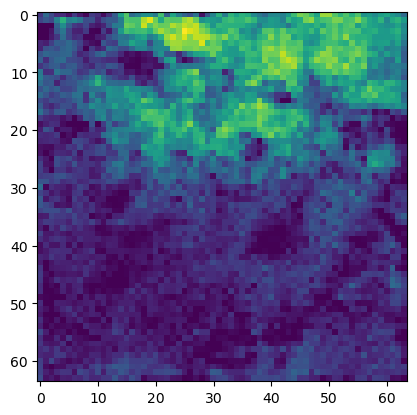

In [11]:
import matplotlib.pyplot as plt
plt.imshow(sample[0, :, :])

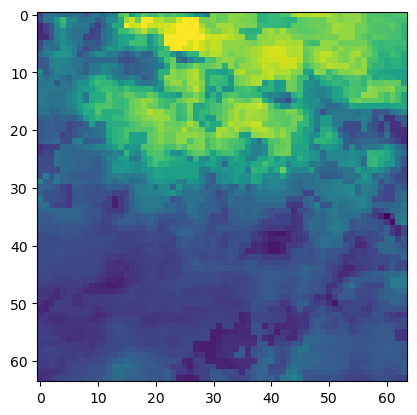

In [13]:
truth = torch.load('/scratch/nf33/cd3022/pyearth/202101010040.pt')
plt.imshow(truth)